# Comparing distances between distributions

[Open in Colab](https://colab.research.google.com/github/andreasmang/stan/blob/main/demos/distances/probdistance.ipynb) &nbsp;·&nbsp; nothing to install &nbsp;·&nbsp; **Runtime > Run all** takes a few seconds

The notebooks `lp.ipynb`, `kl.ipynb`, and `wasserstein.ipynb` each look at one way to measure how different
two distributions $P$ and $Q$ are, with densities $p, q$, CDFs $F, G$, and quantile functions $F^{-1}, G^{-1}$.
Here we run the same examples through all of them:

| | definition | compares |
|---|---|---|
| total variation | $\mathrm{TV} = \tfrac12\int\lvert p-q\rvert\,dx$ | heights of the densities |
| $L^2$ | $\big(\int (p-q)^2\,dx\big)^{1/2}$ | heights of the densities |
| Kullback–Leibler | $\mathrm{KL}(p\,\|\,q) = \int p\log(p/q)\,dx$ | log-ratio of the densities |
| Wasserstein | $W_1 = \int \lvert F-G\rvert\,dx$, $\;W_2 = \big(\int_0^1 (F^{-1}-G^{-1})^2\,du\big)^{1/2}$ | how far mass has to move |

The first two compare $p$ and $q$ at the same $x$, *vertically*. Wasserstein compares where the mass sits, *horizontally*.

In [1]:
import numpy as np, matplotlib.pyplot as plt

x = np.linspace(-40, 40, 16001)                    # grid in x
u = (np.arange(20000) + 0.5) / 20000               # grid in (0, 1) for quantile levels

def log_normal(x, mu=0.0, sigma=1.0):
    return -0.5 * np.log(2 * np.pi * sigma**2) - (x - mu)**2 / (2 * sigma**2)

def cdf(pdf):
    F = np.concatenate([[0], np.cumsum((pdf[1:] + pdf[:-1]) / 2 * np.diff(x))])
    return F / F[-1]

def quantile(F, levels):
    return x[np.minimum(np.searchsorted(F, levels), len(x) - 1)]

# each distance takes the log densities on the grid x
def tv(lp, lq):  return 0.5 * np.trapezoid(np.abs(np.exp(lp) - np.exp(lq)), x)
def l2(lp, lq):  return np.sqrt(np.trapezoid((np.exp(lp) - np.exp(lq))**2, x))
def w1(lp, lq):  return np.trapezoid(np.abs(cdf(np.exp(lp)) - cdf(np.exp(lq))), x)
def kl(lp, lq):
    p = np.exp(lp)
    with np.errstate(invalid="ignore"):
        return np.trapezoid(np.where(p > 0, p * (lp - lq), 0.0), x)

def log_uniform(a, b):
    # density of Uniform(a, b) on the half-open grid interval [a, b), which integrates to exactly 1
    inside = (x >= a - 1e-9) & (x < b - 1e-9)
    with np.errstate(divide="ignore"):
        return np.where(inside, -np.log(b - a), -np.inf)

## 1. Two Gaussians shifted against each other

$P = \mathcal{N}(0,1)$ and $Q = \mathcal{N}(\mu,1)$. The four quantities are in different units, so each gets its own panel.

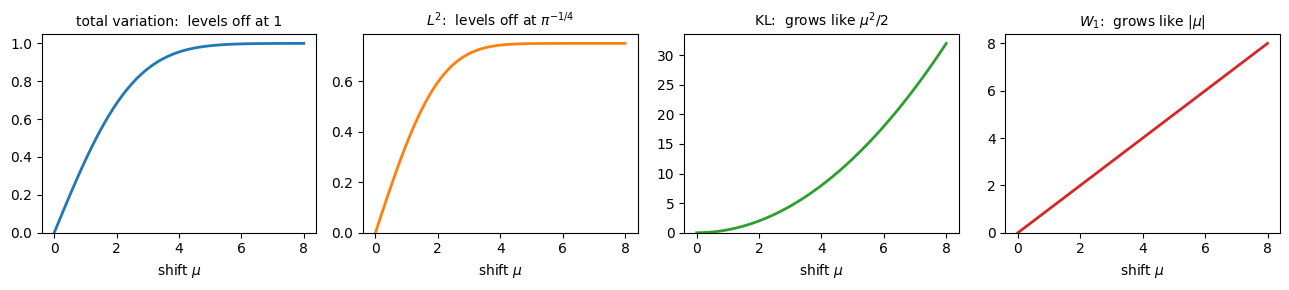

In [2]:
shifts = np.linspace(0, 8, 81)
lp = log_normal(x, 0, 1)
D = {name: np.array([f(lp, log_normal(x, mu, 1)) for mu in shifts])
     for name, f in [("TV", tv), ("L2", l2), ("KL", kl), ("W1", w1)]}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.0))
titles = {"TV": "total variation:  levels off at 1", "L2": r"$L^2$:  levels off at $\pi^{-1/4}$",
          "KL": r"KL:  grows like $\mu^2/2$", "W1": r"$W_1$:  grows like $|\mu|$"}
for ax, (name, col) in zip(axes, [("TV", "C0"), ("L2", "C1"), ("KL", "C2"), ("W1", "C3")]):
    ax.plot(shifts, D[name], col, lw=2)
    ax.set_title(titles[name], fontsize=10); ax.set_xlabel(r"shift $\mu$"); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

* **TV and $L^2$ level off** once the bumps stop overlapping. They answer "do $P$ and $Q$ put their mass in the same
  places?", and past $\mu \approx 4$ the answer is simply no.
* **KL grows without bound**, and faster than the shift itself, because it is driven by how small $q$ is in the
  tails of $p$. For Gaussians that is quadratic in $\mu$; for heavier tails it would be slower.
* **$W_1$ grows exactly like the shift.** It answers "how far does the mass have to move?", which is the
  question a shift actually changes.

## 2. Distributions that do not overlap

$P = \text{Uniform}(0,1)$ and $Q = \text{Uniform}(a, a+1)$, for several gaps $a$.

In [3]:
lp = log_uniform(0, 1)
print(f"{'a':>6} {'TV':>7} {'KL(P||Q)':>9} {'W1':>7}")
for a in [0.25, 0.5, 1, 2, 10]:
    lq = log_uniform(a, a + 1)
    print(f"{a:6} {tv(lp, lq):7.3f} {kl(lp, lq):9} {w1(lp, lq):7.3f}")

     a      TV  KL(P||Q)      W1
  0.25   0.250       inf   0.250
   0.5   0.500       inf   0.500
     1   1.000       inf   1.000
     2   1.000       inf   2.000
    10   1.000       inf  10.000


* **TV** equals $a$ while the uniforms overlap and is stuck at its maximum 1 from $a = 1$ on: a gap of 2 and a gap of 10 look the same.
* **KL is infinite for every $a > 0$**, even for $a = 0.25$, when the two overlap on 75% of their mass: $P$ puts mass on $[0, a)$, where $q = 0$.
* **$W_1 = a$** throughout: every bit of mass moves by $a$.

## 3. Changing units

The same pair of distributions in different units: $P = \mathcal{N}(0,\sigma^2)$ and $Q = \mathcal{N}(\sigma,\sigma^2)$, a shift of
one standard deviation.

In [4]:
print(f"{'sigma':>6} {'TV':>7} {'L2':>7} {'KL':>7} {'W1':>7}")
for sigma in [0.5, 1, 2, 4]:
    lp, lq = log_normal(x, 0, sigma), log_normal(x, sigma, sigma)
    print(f"{sigma:6} {tv(lp, lq):7.4f} {l2(lp, lq):7.4f} {kl(lp, lq):7.4f} {w1(lp, lq):7.4f}")

 sigma      TV      L2      KL      W1
   0.5  0.3829  0.4996  0.5000  0.5000
     1  0.3829  0.3533  0.5000  1.0000
     2  0.3829  0.2498  0.5000  2.0000
     4  0.3829  0.1766  0.5000  4.0000


* **TV and KL do not change**: they only depend on probabilities of events, so they are the same in any units.
* **$L^2$ changes** ($\propto \sigma^{-1/2}$) for no good reason: a density has units of $1/x$.
* **$W_1$ changes** ($\propto \sigma$), and for a good reason: it is a distance in the units of $x$. A shift of 1 cm is
  0.01 m. Whether that is what you want depends on whether the geometry of $x$ matters to the problem.

## 4. How TV and KL are related: Pinsker's inequality

TV and KL measure different things, but they are tied together by **Pinsker's inequality**:

$$\mathrm{TV}(P,Q) \;\le\; \sqrt{\tfrac12\,\mathrm{KL}(p\,\|\,q)} .$$

TV is symmetric, so the bound holds with either order of the KL arguments, and hence with the smaller of the two.
Check it on the shifted Gaussians from Section 1, and on 300 random pairs of Gaussians.

Pinsker holds for 300 of 300 random pairs


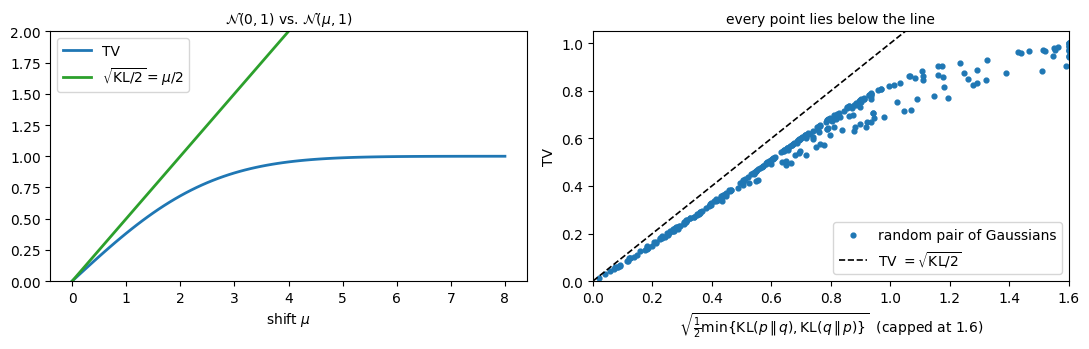

In [5]:
rng = np.random.default_rng(166)
pairs = []
for _ in range(300):
    m1, m2 = rng.uniform(-3, 3, 2)
    s1, s2 = rng.uniform(0.3, 3, 2)
    lp, lq = log_normal(x, m1, s1), log_normal(x, m2, s2)
    pairs.append((tv(lp, lq), min(kl(lp, lq), kl(lq, lp))))
TVr, KLr = np.array(pairs).T
bound = np.sqrt(KLr / 2)
print(f"Pinsker holds for {np.sum(TVr <= bound + 1e-9)} of {len(TVr)} random pairs")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.6))
ax0.plot(shifts, D["TV"], "C0", lw=2, label="TV")
ax0.plot(shifts, np.sqrt(D["KL"] / 2), "C2", lw=2, label=r"$\sqrt{\mathrm{KL}/2} = \mu/2$")
ax0.set_ylim(0, 2); ax0.set_xlabel(r"shift $\mu$"); ax0.legend(loc="upper left")
ax0.set_title(r"$\mathcal{N}(0,1)$ vs. $\mathcal{N}(\mu,1)$", fontsize=10)
ax1.scatter(np.minimum(bound, 1.6), TVr, s=12, color="C0", label="random pair of Gaussians")
ax1.plot([0, 1.6], [0, 1.6], "k--", lw=1.2, label=r"TV $=\sqrt{\mathrm{KL}/2}$")
ax1.set_xlim(0, 1.6); ax1.set_ylim(0, 1.05); ax1.legend(loc="lower right")
ax1.set_xlabel(r"$\sqrt{\frac{1}{2}\min\{\mathrm{KL}(p\,\|\,q), \mathrm{KL}(q\,\|\,p)\}}$  (capped at 1.6)")
ax1.set_ylabel("TV"); ax1.set_title("every point lies below the line", fontsize=10)
plt.tight_layout(); plt.show()

The bound is tight for nearby distributions (small $\mu$) and useless for distant ones, since TV never exceeds 1.
It works in one direction only:

* **small KL forces small TV.** If a model $q$ is close to $p$ in KL, then every event has nearly the same probability under both;
* **small TV does not force small KL.** In Section 2, $\text{Uniform}(0,1)$ and $\text{Uniform}(0.25, 1.25)$ have $\mathrm{TV} = 0.25$ but $\mathrm{KL} = \infty$.

So closeness in KL is a stronger requirement than closeness in TV.

## 5. A Gaussian against a mixture of two Gaussians

Let $P$ have two modes, $p = \tfrac12\,\mathcal{N}(-3,1) + \tfrac12\,\mathcal{N}(3,1)$, and slide a single Gaussian
$Q = \mathcal{N}(m, 1)$ across it.

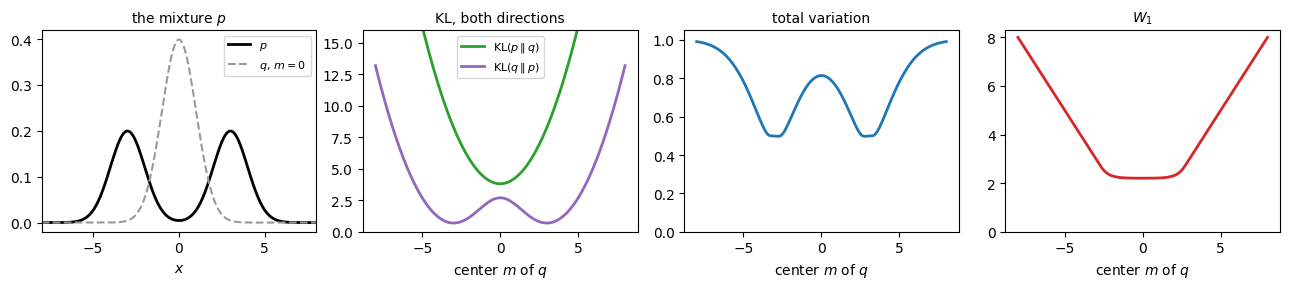

      m =       0     1.5       3
 KL(p||q)   3.811   4.936   8.311
 KL(q||p)   2.693   1.606   0.689
       TV   0.814   0.677   0.499
       W1   2.203   2.235   3.000


In [6]:
d = 3.0
lp = np.logaddexp(np.log(0.5) + log_normal(x, -d, 1), np.log(0.5) + log_normal(x, d, 1))
ms = np.linspace(-8, 8, 161)
fwd = np.array([kl(lp, log_normal(x, m, 1)) for m in ms])
rev = np.array([kl(log_normal(x, m, 1), lp) for m in ms])
TV  = np.array([tv(lp, log_normal(x, m, 1)) for m in ms])
W1  = np.array([w1(lp, log_normal(x, m, 1)) for m in ms])

fig, axes = plt.subplots(1, 4, figsize=(13, 3.0))
axes[0].plot(x, np.exp(lp), "k", lw=2, label="$p$")
axes[0].plot(x, np.exp(log_normal(x, 0, 1)), "0.6", lw=1.5, ls="--", label="$q$, $m = 0$")
axes[0].set_xlim(-8, 8); axes[0].set_title("the mixture $p$", fontsize=10); axes[0].legend(fontsize=8)
axes[1].plot(ms, fwd, "C2", lw=2, label=r"$\mathrm{KL}(p\,\|\,q)$")
axes[1].plot(ms, rev, "C4", lw=2, label=r"$\mathrm{KL}(q\,\|\,p)$")
axes[1].set_ylim(0, 16); axes[1].set_title("KL, both directions", fontsize=10); axes[1].legend(loc="upper center", fontsize=8)
axes[2].plot(ms, TV, "C0", lw=2); axes[2].set_ylim(0, 1.05); axes[2].set_title("total variation", fontsize=10)
axes[3].plot(ms, W1, "C3", lw=2); axes[3].set_ylim(bottom=0); axes[3].set_title("$W_1$", fontsize=10)
for ax in axes[1:]:
    ax.set_xlabel("center $m$ of $q$")
axes[0].set_xlabel("$x$")
plt.tight_layout(); plt.show()

show = [0, 1.5, 3]                                       # everything is symmetric in m
print(f"{'m =':>9}" + "".join(f"{m:>8}" for m in show))
for name, vals in [("KL(p||q)", fwd), ("KL(q||p)", rev), ("TV", TV), ("W1", W1)]:
    print(f"{name:>9}" + "".join(f"{vals[np.argmin(np.abs(ms - m))]:8.3f}" for m in show))

With the spread of $q$ held at 1, the four disagree about where $q$ should go:

* $\mathrm{KL}(p\,\|\,q)$ puts $q$ **between** the modes, at $m = 0$, where $p$ itself has almost no mass, because $q$ must not be tiny
  anywhere $p$ has mass.
* $W_1$ is also smallest at $m = 0$, but only just: it is **nearly flat between the modes** (2.20 at $m = 0$, 2.23 at $m = 1.5$).
  Moving $q$ towards one mode shortens the trip for that half of the mass by almost as much as it lengthens the trip
  for the other half.
* $\mathrm{KL}(q\,\|\,p)$ and TV put $q$ **on (or next to) one of the modes**. $\mathrm{KL}(q\,\|\,p)$ does it because $q$ must not put mass where $p$ is tiny;
  TV because there $q$ overlaps half of $p$, while at $m = 0$ it overlaps almost nothing.

Now let the spread vary too, and find the best Gaussian $\mathcal{N}(m, s^2)$ under each criterion (on a grid of $m$ and $s$).

best Gaussian for  KL(p||q):  N(+0.0, 3.15^2)
best Gaussian for  KL(q||p):  N(-3.0, 1.00^2)
best Gaussian for        TV:  N(+0.0, 3.20^2)
best Gaussian for        W2:  N(+0.0, 2.95^2)
(the mixture has mean 0 and standard deviation sqrt(1 + d^2) = 3.16)


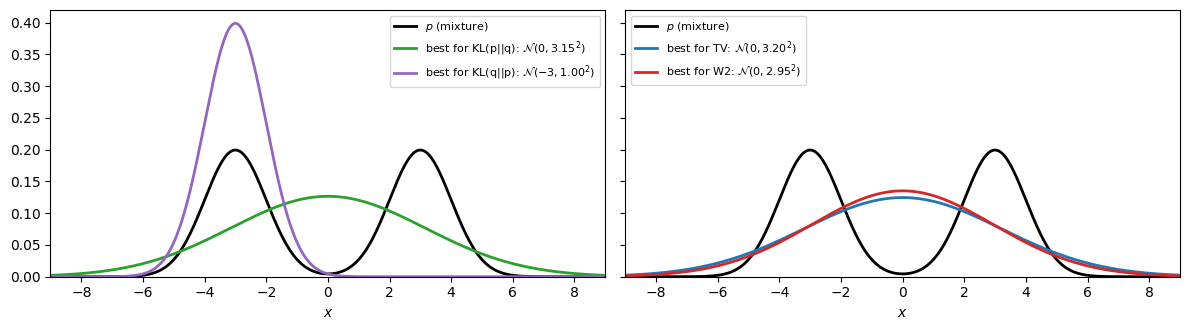

In [7]:
p = np.exp(lp)
Qp = quantile(cdf(p), u)                              # quantile function of the mixture
z = quantile(cdf(np.exp(log_normal(x))), u)           # standard normal quantiles
m_grid, s_grid = np.linspace(-5, 5, 101), np.linspace(0.5, 4.5, 81)
crit = {k: np.empty((s_grid.size, m_grid.size)) for k in ["KL(p||q)", "KL(q||p)", "TV", "W2"]}
for i, s in enumerate(s_grid):
    lq = log_normal(x[None, :], m_grid[:, None], s)   # one row per m
    q = np.exp(lq)
    crit["KL(p||q)"][i] = np.trapezoid(p * (lp - lq), x, axis=1)
    crit["KL(q||p)"][i] = np.trapezoid(q * (lq - lp), x, axis=1)
    crit["TV"][i] = 0.5 * np.trapezoid(np.abs(p - q), x, axis=1)
    crit["W2"][i] = np.sqrt(np.mean((Qp - m_grid[:, None] - s * z)**2, axis=1))   # quantiles of q: m + s z

best = {}
for k, A in crit.items():
    i, j = np.unravel_index(A.argmin(), A.shape)
    best[k] = (m_grid[j], s_grid[i])
    print(f"best Gaussian for {k:>9}:  N({m_grid[j]:+.1f}, {s_grid[i]:.2f}^2)")
print(f"(the mixture has mean 0 and standard deviation sqrt(1 + d^2) = {np.sqrt(1 + d**2):.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, pair, loc in zip(axes, [[("KL(p||q)", "C2"), ("KL(q||p)", "C4")], [("TV", "C0"), ("W2", "C3")]], ["upper right", "upper left"]):
    ax.plot(x, p, "k", lw=2, label="$p$ (mixture)")
    for k, col in pair:
        m, s = best[k]
        ax.plot(x, np.exp(log_normal(x, m, s)), col, lw=2, label=f"best for {k}: $\\mathcal{{N}}({m:.0f}, {s:.2f}^2)$")
    ax.set_xlim(-9, 9); ax.set_ylim(0, 0.42); ax.set_xlabel("$x$"); ax.legend(loc=loc, fontsize=8)
plt.tight_layout(); plt.show()

Once $q$ may be wide, three of the four choose a **broad Gaussian over both modes**: $\mathrm{KL}(p\,\|\,q)$ matches the mean and
variance of $p$ exactly (this is what maximum likelihood does, see `kl.ipynb`), and TV and $W_2$ land close to it.
Only $\mathrm{KL}(q\,\|\,p)$ **picks one mode** and fits it tightly. A single-mode fit is not wrong; it is the right answer to a
different question ("find a region where $p$ is large"), and it is why the order of the arguments of KL must always be stated.

## 6. From data

In practice $P$ is known only through a sample $X_1, \dots, X_n$, and the natural estimate is the empirical distribution $\widehat P_n$,
which puts mass $1/n$ on each $X_i$. How far is it from $P = \mathcal{N}(0,1)$?

* **TV** is always 1: the event $A = \{X_1, \dots, X_n\}$ has $\widehat P_n(A) = 1$ and $P(A) = 0$.
* **KL** is infinite in both directions, by the same event: one of the two distributions puts all its mass on $A$, the other none.
* **$W_1$** shrinks to 0, like $1/\sqrt{n}$:

In [8]:
rng = np.random.default_rng(166)
F = cdf(np.exp(log_normal(x)))
for n in [10, 100, 1000, 10000]:
    s = np.sort(rng.normal(0, 1, n))
    Fn = np.searchsorted(s, x, side="right") / n
    print(f"n = {n:6d}:  W1(empirical, N(0,1)) = {np.trapezoid(np.abs(Fn - F), x):.4f}   TV = 1,  KL = inf")

n =     10:  W1(empirical, N(0,1)) = 0.2950   TV = 1,  KL = inf
n =    100:  W1(empirical, N(0,1)) = 0.0906   TV = 1,  KL = inf
n =   1000:  W1(empirical, N(0,1)) = 0.0291   TV = 1,  KL = inf
n =  10000:  W1(empirical, N(0,1)) = 0.0122   TV = 1,  KL = inf


Density-based distances can only be computed from data after estimating a density first (with a histogram or
a kernel density estimate), and the answer then depends on that choice. Wasserstein works with the data directly.

## Summary

| | TV ($= \tfrac12 L^1$) | $L^2$, $L^\infty$ | KL | Wasserstein |
|---|---|---|---|---|
| symmetric | yes | yes | **no** | yes |
| true distance (triangle inequality) | yes | yes | no | yes |
| largest possible value | 1 | no bound in general | $\infty$ | $\infty$ ($W_r$ is finite if $\mathbb{E}\lvert X\rvert^r$ is) |
| no overlap at all | maximal | maximal | $\infty$ | how far apart |
| independent of units of $x$ | yes | no | yes | no: in units of $x$ |
| useful directly on a sample | no (always 1) | no | no ($\infty$) | **yes** |
| where it shows up | hypothesis testing, probability bounds | density estimation | likelihood, information theory | optimal transport, generative models |

No one distance is best. TV asks *can an event tell the two apart?*, KL asks *how surprised would a model $q$ be by data
from $p$?*, and Wasserstein asks *how far does the mass have to move?* Choose the one that asks your question.

---

This notebook is part of [STAN](https://github.com/andreasmang/stan), the code repository
for MATH 166 (Statistics) at Tufts University. 